# Separation Of Variable, Spherical Coordinates

_Refreshed: 2025-10-22_

---

## Table of Contents
  - [Solving the left side:](#solving-the-left-side)
  - [Solving the right side](#solving-the-right-side)
  - [Legendre Polynomials](#legendre-polynomials)


# Separation of Variables in Spherical Coordinates — Why Legendre?

_Refreshed: 2025-10-22_

## Learning objectives
- Apply separation of variables (SoV) to Laplace/Helmholtz equations in spherical coordinates.
- Derive the **radial** and **angular** ODEs and identify the separation constant $(\ell(\ell+1))$.
- See why the angular equation is a **Sturm–Liouville** problem on $([0,\pi])$ with weight $(\sin\theta)$, whose eigenfunctions are **Legendre** / **associated Legendre** polynomials.
- Know when to use **spherical harmonics** $(Y_\ell^m(\theta,\phi))$ vs. axisymmetric $(P_\ell(\cos\theta))$ (when $(m=0)$).

---

## Big picture
Separating $(u(r,\theta,\phi)=R(r)\,\Theta(\theta)\,\Phi(\phi))$ in the spherical Laplacian yields three ODEs.
The $(\phi)$-part gives Fourier modes $(e^{im\phi})$.
The $(\theta)$-part is a self-adjoint eigenproblem with weight $(\sin\theta)$, giving **associated Legendre** functions.
The radial equation becomes Euler/Cauchy type for Laplace (or spherical Bessel for Helmholtz).

The ubiquitous $(\ell(\ell+1))$ appears as the eigenvalue of
$$
\mathcal L_\theta[\Theta] = \frac{1}{\sin\theta}\frac{d}{d\theta}\!\left(\sin\theta\,\Theta'\right) - \frac{m^2}{\sin^2\theta}\,\Theta.
$$
Regular solutions on $([0,\pi])$ are $(\Theta\propto P_\ell^m(\cos\theta))$.


In [1]:
# SymPy check: angular ODE → associated Legendre
from sympy import symbols, Function, Eq, dsolve, diff, cos

theta, x, l, m = symbols('theta x l m', integer=True, nonnegative=True)
Y = Function('Y')

ode_x = Eq((1 - x**2)*diff(Y(x), x, 2) - 2*x*diff(Y(x), x) + (l*(l+1) - m**2/(1 - x**2))*Y(x), 0)
sol_x = dsolve(ode_x, Y(x))
sol_theta = sol_x.subs(x, cos(theta))
sol_theta

Eq(Y(cos(theta)), 9*r(3)*cos(theta)**5/10 + m**2*r(3)*cos(theta)**5/20 - l*r(3)*cos(theta)**5/20 - l**2*r(3)*cos(theta)**5/20 + C2*(l**4*cos(theta)**4/24 + l**3*cos(theta)**4/12 - l**2*m**2*cos(theta)**4/12 - 5*l**2*cos(theta)**4/24 - l**2*cos(theta)**2/2 - l*m**2*cos(theta)**4/12 - l*cos(theta)**4/4 - l*cos(theta)**2/2 + m**4*cos(theta)**4/24 + m**2*cos(theta)**4/3 + m**2*cos(theta)**2/2 + 1) + C1*(l**2*cos(theta)**4/20 + l*cos(theta)**4/20 - cos(theta)**4/10 + 1)*cos(theta) + O((theta - pi/2)**6, (theta, pi/2)))

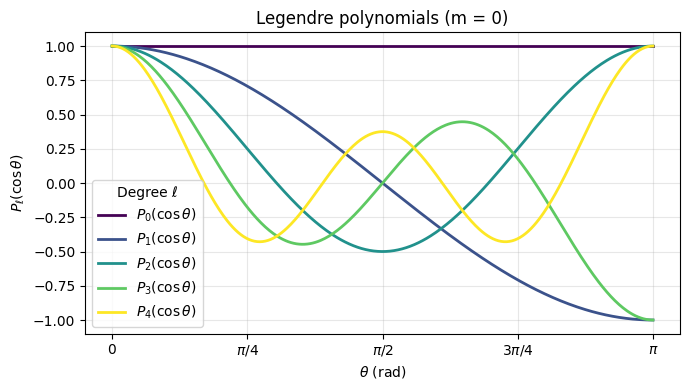

In [2]:
# Nicely labeled plot of P0–P4(cos θ)
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, legendre, lambdify

theta = np.linspace(0, np.pi, 400)
x = np.cos(theta)

xx = symbols('xx', real=True)
funcs = [lambdify(xx, legendre(n, xx), 'numpy') for n in range(5)]

def eval_safe(f, arr):
    y = np.asarray(f(arr))
    if y.shape == (): y = np.broadcast_to(y, arr.shape)
    return y.reshape(arr.shape)

plt.figure(figsize=(7,4))
for n, c in zip(range(5), plt.cm.viridis(np.linspace(0,1,5))):
    y = eval_safe(funcs[n], x)
    plt.plot(theta, y, label=fr"$P_{{{n}}}(\cos\theta)$", color=c, lw=2)

plt.xlabel(r"$\theta$ (rad)"); plt.ylabel(r"$P_\ell(\cos\theta)$")
plt.title("Legendre polynomials (m = 0)")
plt.xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
           [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
plt.grid(alpha=0.3); plt.legend(title="Degree ℓ", frameon=True, fontsize=10)
plt.tight_layout(); plt.show()


### Common pitfalls
- Use `Eq(lhs, 0)` for homogeneous ODEs in SymPy (don’t omit the RHS).
- Write the angular ODE in canonical Legendre form by substituting \\(x=\cos\theta\\) **before** `dsolve`.
- Choose the **regular** radial branch at the origin: \\(R\propto r^\ell\\) (for Laplace).


In [3]:
# Common utilities for this notebook (2025 refresh)
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 140, "figure.autolayout": True})

def savefig(name: str, dpi: int = 220):
    """
    Save a figure as PNG and SVG to the local 'figures' folder.
    """
    import os
    os.makedirs("figures", exist_ok=True)
    if not name.lower().endswith(".png"):
        png = f"{name}.png"
        svg = f"{name}.svg"
    else:
        png = name
        svg = name.replace(".png", ".svg")
    plt.savefig(os.path.join("figures", png), dpi=dpi, bbox_inches="tight")
    plt.savefig(os.path.join("figures", svg), bbox_inches="tight")
    print(f"Saved figures/{png} and figures/{svg}")

# Separation of Variables in spherical coordinates

with the Laplace equation in spherical coordiantes:

$$ \frac{1}{r^2}\frac{\partial}{\partial r}\left (r^2 \frac{\partial V}{\partial r}\right )+ 
   \frac{1}{r^2\sin \theta}\frac{\partial}{\partial \theta} \left (\sin \theta \frac{\partial V}{\partial \theta}\right )+
   \frac{1}{r^2\sin^2 \theta}\frac{\partial^2 V}{\partial \phi^2}
   =0
$$

we are assuming azimuthal symmetry here and ths V is independent of $\phi$, even though the general care is solveable as well and it simplifies to:

$$ \frac{\partial}{\partial r}\left (r^2 \frac{\partial V}{\partial r}\right )+ 
   \frac{1}{\sin \theta}\frac{\partial}{\partial \theta} \left (\sin \theta \frac{\partial V}{\partial \theta}\right )
   =0
$$

Again we are looking for solutions as products:
    
$$ V(r,\theta) = R(r)\Theta(\theta)$$

Separating of variables gives us:
    
$$ \frac 1 R \frac{\partial}{\partial r}\left (r^2 \frac{\partial R}{\partial r}\right )= 
   -\frac{1}{\Theta\sin \theta}\frac{\partial}{\partial \theta} \left (\sin \theta \frac{\partial \Theta}{\partial \theta}\right ) $$
   
which can only be equal if the left side and the right side are constants (since they each only depend on $r$ or $\theta$ respectively)

So we are setting constants for the left side:

    
$$ \frac 1 R \frac{\partial}{\partial r}\left (r^2 \frac{\partial R}{\partial r}\right )=
   l(l+1)$$
   
and for the right side:
$$ \frac{1}{\Theta\sin \theta}\frac{\partial}{\partial \theta} \left (\sin \theta \frac{\partial \Theta}{\partial \theta}\right ) = - l(l+1) $$

and thus have converted a PDE in two ODEs.

### Solving the left side:

In [4]:
from sympy.interactive import printing # use latex for printing
printing.init_printing(use_latex=True)
from sympy import Function, dsolve, Eq, Derivative, sin, cos, symbols # import necessary methods
from sympy.abc import theta # import variables

In [5]:
r, l = symbols('r l',positive=True)
R = Function('R',real=True)
s1_ode = Eq(Derivative((r**2*Derivative(R(r),r,1)), r, 1)-l*(l+1)*R(r), 0)
s1_ode

In [6]:
sol1 = dsolve(s1_ode, R(r))
sol1

With $C_1\equiv A$ and $C_2\equiv B$ being constants to be determined.

### Solving the right side

In [7]:
t, l = symbols('theta l')
T = Function('Theta',real=True)
s2_ode = Eq(Derivative(sin(t)*Derivative(T(t),t,1), t, 1)+l*(l+1)*sin(t)*T(t),0)
s2_ode

However, this is not easy to solve ...

In [8]:
sol2 = dsolve(s2_ode, T(t))
sol2

NotImplementedError: The given ODE -(-l**2*Theta(theta) - l*Theta(theta) - Derivative(Theta(theta), (theta, 2)))*tan(theta) + Derivative(Theta(theta), theta) cannot be solved by the factorable group method

### Legendre Polynomials

It turns out Legendre Polynomal are solutions in the variable of $\cos \theta$

In [ ]:
from sympy.plotting import plot
from sympy import legendre, pi
%matplotlib inline

Fortunately sympy knows them

In [ ]:
t = symbols('theta',positive=True)
P0 = lambda t: legendre(0,t)
P1 = lambda t: legendre(1,t)
P2 = lambda t: legendre(2,t)
P3 = lambda t: legendre(3,t)
P4 = lambda t: legendre(4,t)

In [ ]:
P0(cos(t))

In [ ]:
P1(cos(t))

In [ ]:
P2(cos(t))

In [ ]:
P3(cos(t))

In [ ]:
P4(cos(t))

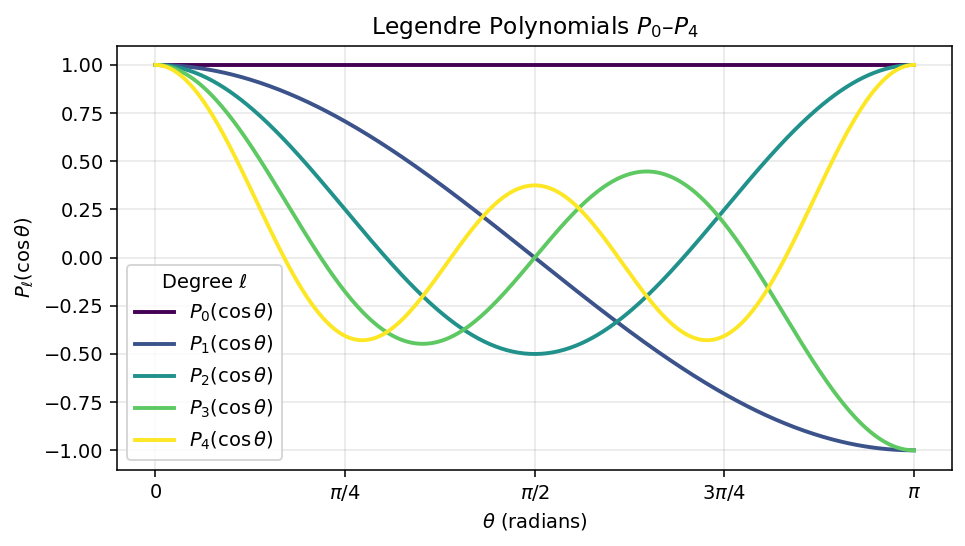

In [ ]:
from sympy import symbols, legendre, lambdify

# --- Fresh namespace variables (avoid collisions) ---
theta = np.linspace(0, np.pi, 400)          # θ grid (400,)
x_vals = np.cos(theta)                       # x = cos θ, same shape as theta

# Build P_l(x) for l = 0..4 and lambdify in x
x = symbols('x', real=True)
P_funcs = [lambdify(x, legendre(n, x), modules="numpy") for n in range(5)]

def eval_legendre_safe(fn, xgrid):
    """Evaluate possibly-scalar lambdify outputs and broadcast to xgrid shape."""
    y = np.asarray(fn(xgrid))
    if y.shape == ():               # scalar -> broadcast
        y = np.broadcast_to(y, xgrid.shape)
    else:
        y = y.reshape(xgrid.shape)  # ensure 1-D match
    return y

# Plot
plt.figure(figsize=(7, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(P_funcs)))
for n, fn, c in zip(range(5), P_funcs, colors):
    y = eval_legendre_safe(fn, x_vals)
    plt.plot(theta, y, label=fr"$P_{{{n}}}(\cos\theta)$", color=c, linewidth=2)

plt.xlabel(r"$\theta$ (radians)")
plt.ylabel(r"$P_\ell(\cos\theta)$")
plt.title("Legendre Polynomials $P_0$–$P_4$")
plt.xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
           [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
plt.grid(alpha=0.3)
plt.legend(title="Degree ℓ", frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


Legendre polynomials with the argument $\cos\theta$ are the solutions for the right side:

$$ \Theta(\theta) = P_l(\cos\theta) $$

Which gives the most general separabe solution to Laplace equation (for physics):

$$ V(r,\theta)=\sum_{l=0}^{\infty}\left (A_l r^l+\frac{B_l}{r^{l+1}}\right ) P_l(\cos\theta) $$